In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split, cross_validate, StratifiedKFold
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    classification_report,
    ConfusionMatrixDisplay,
    roc_curve,
)

In [2]:
# constants

DATA_PATH = "../datasets/Breast_Cancer.csv"
TARGET = "Status"
RANDOM_STATE = 13
TEST_SIZE = 0.2

CATEGORICAL_FEATURES = [
    "Race",
    "Marital Status",
    "T Stage ",
    "N Stage",
    "6th Stage",
    "differentiate",
    "Grade",
    "A Stage",
    "Estrogen Status",
    "Progesterone Status",
]

NUMERIC_FEATURES = [
    "Age",
    "Tumor Size",
    "Regional Node Examined",
    "Reginol Node Positive",
    "Survival Months",
]

In [3]:
# data overview
data = pd.read_csv(DATA_PATH)

# pd.set_option('display.max_columns', None)
print(data.shape)
display(data.head())
data.info()
data.isna().sum()

(4024, 16)


,Age,Race,Marital Status,T Stage,N Stage,6th Stage,differentiate,Grade,A Stage,Tumor Size,Estrogen Status,Progesterone Status,Regional Node Examined,Reginol Node Positive,Survival Months,Status
0,68,White,Married,T1,N1,IIA,Poorly differentiated,3,Regional,4,Positive,Positive,24,1,60,Alive
1,50,White,Married,T2,N2,IIIA,Moderately differentiated,2,Regional,35,Positive,Positive,14,5,62,Alive
2,58,White,Divorced,T3,N3,IIIC,Moderately differentiated,2,Regional,63,Positive,Positive,14,7,75,Alive
3,58,White,Married,T1,N1,IIA,Poorly differentiated,3,Regional,18,Positive,Positive,2,1,84,Alive
4,47,White,Married,T2,N1,IIB,Poorly differentiated,3,Regional,41,Positive,Positive,3,1,50,Alive


<class 'pandas.DataFrame'>
RangeIndex: 4024 entries, 0 to 4023
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   Age                     4024 non-null   int64
 1   Race                    4024 non-null   str  
 2   Marital Status          4024 non-null   str  
 3   T Stage                 4024 non-null   str  
 4   N Stage                 4024 non-null   str  
 5   6th Stage               4024 non-null   str  
 6   differentiate           4024 non-null   str  
 7   Grade                   4024 non-null   str  
 8   A Stage                 4024 non-null   str  
 9   Tumor Size              4024 non-null   int64
 10  Estrogen Status         4024 non-null   str  
 11  Progesterone Status     4024 non-null   str  
 12  Regional Node Examined  4024 non-null   int64
 13  Reginol Node Positive   4024 non-null   int64
 14  Survival Months         4024 non-null   int64
 15  Status                  4024 non

Age                       0
Race                      0
Marital Status            0
T Stage                   0
N Stage                   0
6th Stage                 0
differentiate             0
Grade                     0
A Stage                   0
Tumor Size                0
Estrogen Status           0
Progesterone Status       0
Regional Node Examined    0
Reginol Node Positive     0
Survival Months           0
Status                    0
dtype: int64

In [4]:
X = data.drop(columns=TARGET)
y = data[TARGET].map({"Dead": 1, "Alive": 0})

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)

In [6]:
# data preprocessing pipelines

numeric_pipeline = Pipeline(
    [
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

categorical_pipeline = Pipeline(
    [
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("ohe", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
    ]
)

preprocessor = ColumnTransformer(
    [
        ("num", numeric_pipeline, NUMERIC_FEATURES),
        ("cat", categorical_pipeline, CATEGORICAL_FEATURES),
    ]
)

In [7]:
# full model pipeline

model = Pipeline(
    [("preprocessor", preprocessor), ("clf", LogisticRegression(max_iter=1000))]
)

In [8]:
# cross-validation, important to do before training

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "roc_auc": "roc_auc",
}

cv_results = cross_validate(
    estimator=model,
    X=X_train,
    y=y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=-1,
    return_train_score=True,
)

print("CV accuracy:", cv_results["test_accuracy"])
print("Mean CV accuracy:", cv_results["test_accuracy"].mean())

print("CV precision:", cv_results["test_precision"])
print("Mean CV precision:", cv_results["test_precision"].mean())

print("CV recall:", cv_results["test_recall"])
print("Mean CV recall:", cv_results["test_recall"].mean())

print("CV ROC-AUC:", cv_results["test_roc_auc"])
print("Mean CV ROC-AUC:", cv_results["test_roc_auc"].mean())

print("Mean fit time:", cv_results["fit_time"].mean())
print("Mean score time:", cv_results["score_time"].mean())

CV accuracy: [0.90372671 0.89440994 0.89440994 0.87888199 0.88180404]
Mean CV accuracy: 0.89064652299489
CV precision: [0.8        0.79245283 0.73134328 0.72340426 0.7037037 ]
Mean CV precision: 0.7501808145587243
CV recall: [0.48979592 0.42424242 0.49494949 0.34343434 0.3877551 ]
Mean CV recall: 0.42803545660688513
CV ROC-AUC: [0.87278538 0.85439718 0.85569456 0.85033824 0.86206703]
Mean CV ROC-AUC: 0.8590564788973326
Mean fit time: 0.033972883224487306
Mean score time: 0.023149776458740234


In [9]:
model.fit(X_train, y_train)
None

In [10]:
y_prob = model.predict_proba(X_test)

threshold = 0.3
y_pred = (y_prob[:, 1] >= threshold).astype(int)

In [11]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print(classification_report(y_test, y_pred))

Accuracy: 0.8881987577639752
Precision: 0.6386554621848739
Recall: 0.6178861788617886
              precision    recall  f1-score   support

           0       0.93      0.94      0.93       682
           1       0.64      0.62      0.63       123

    accuracy                           0.89       805
   macro avg       0.79      0.78      0.78       805
weighted avg       0.89      0.89      0.89       805



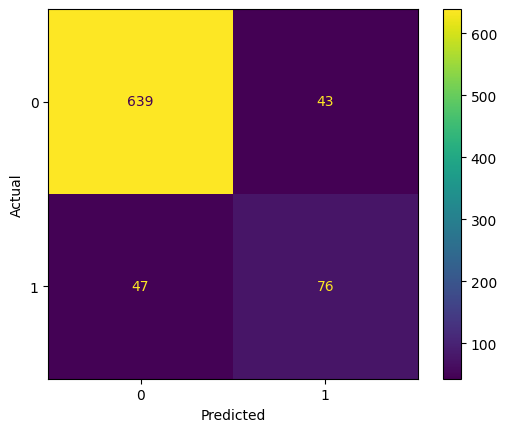

In [12]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

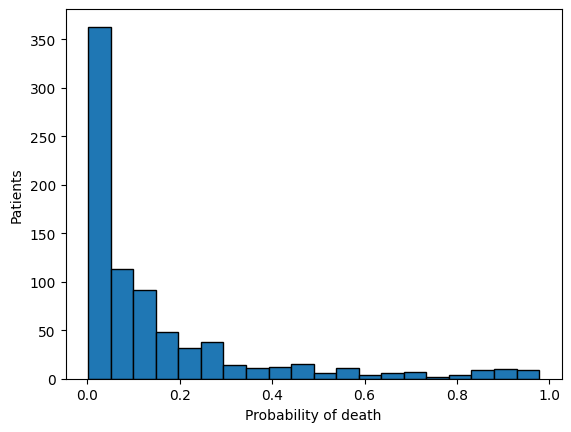

In [13]:
plt.hist(y_prob[:, 1], bins=20, edgecolor="black")
plt.xlabel("Probability of death")
plt.ylabel("Patients")
plt.show()

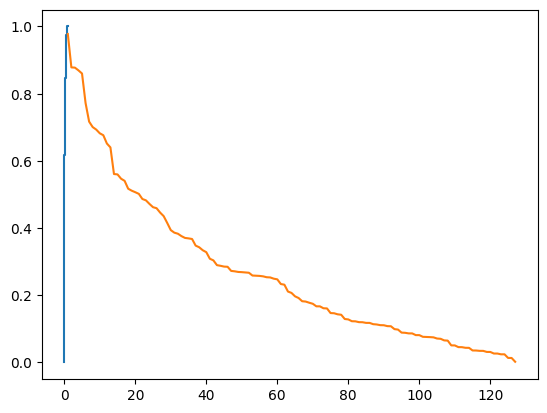

In [14]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob[:, 1])
plt.plot(fpr, tpr, thresholds)